# Exploratory Data Analysis

Overview of the Kaggle Playground Series S6E2 Heart Disease dataset.
630K synthetic samples generated from the 270-row UCI Cleveland original.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

## 1. Load Data

In [2]:
train = pd.read_csv('../data/competition/train.csv')
original = pd.read_csv('../data/competition/original.csv')

print(f'Competition train: {train.shape[0]:,} rows, {train.shape[1]} columns')
print(f'Original UCI: {original.shape[0]} rows, {original.shape[1]} columns')
train.head()

Competition train: 630,000 rows, 15 columns
Original UCI: 270 rows, 14 columns


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


## 2. Basic Statistics

In [3]:
print('Data types:')
print(train.dtypes)
print(f'\nMissing values: {train.isnull().sum().sum()}')
print(f'\nTarget distribution:')
print(train['Heart Disease'].value_counts())
print(f'\nTarget prevalence: {(train["Heart Disease"] == "Presence").mean():.1%}')

Data types:
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

Missing values: 0

Target distribution:
Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Target prevalence: 44.8%


In [4]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


## 3. Class Balance

The competition dataset is nearly balanced, unlike the original UCI Cleveland
which has ~46% disease prevalence.

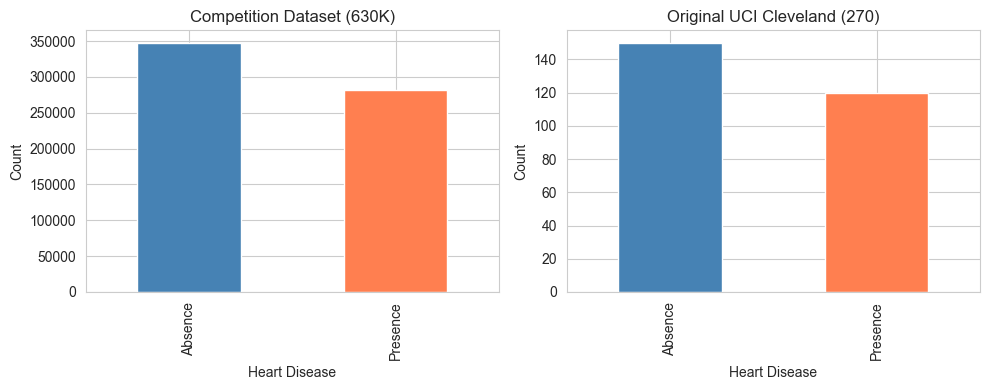

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train['Heart Disease'].value_counts().plot.bar(ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Competition Dataset (630K)')
axes[0].set_ylabel('Count')

original['Heart Disease'].value_counts().plot.bar(ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Original UCI Cleveland (270)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../results/figures/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Distributions by Target

All 13 clinical features, split by disease presence/absence.
Numerical features show histograms; categorical features show count bars.

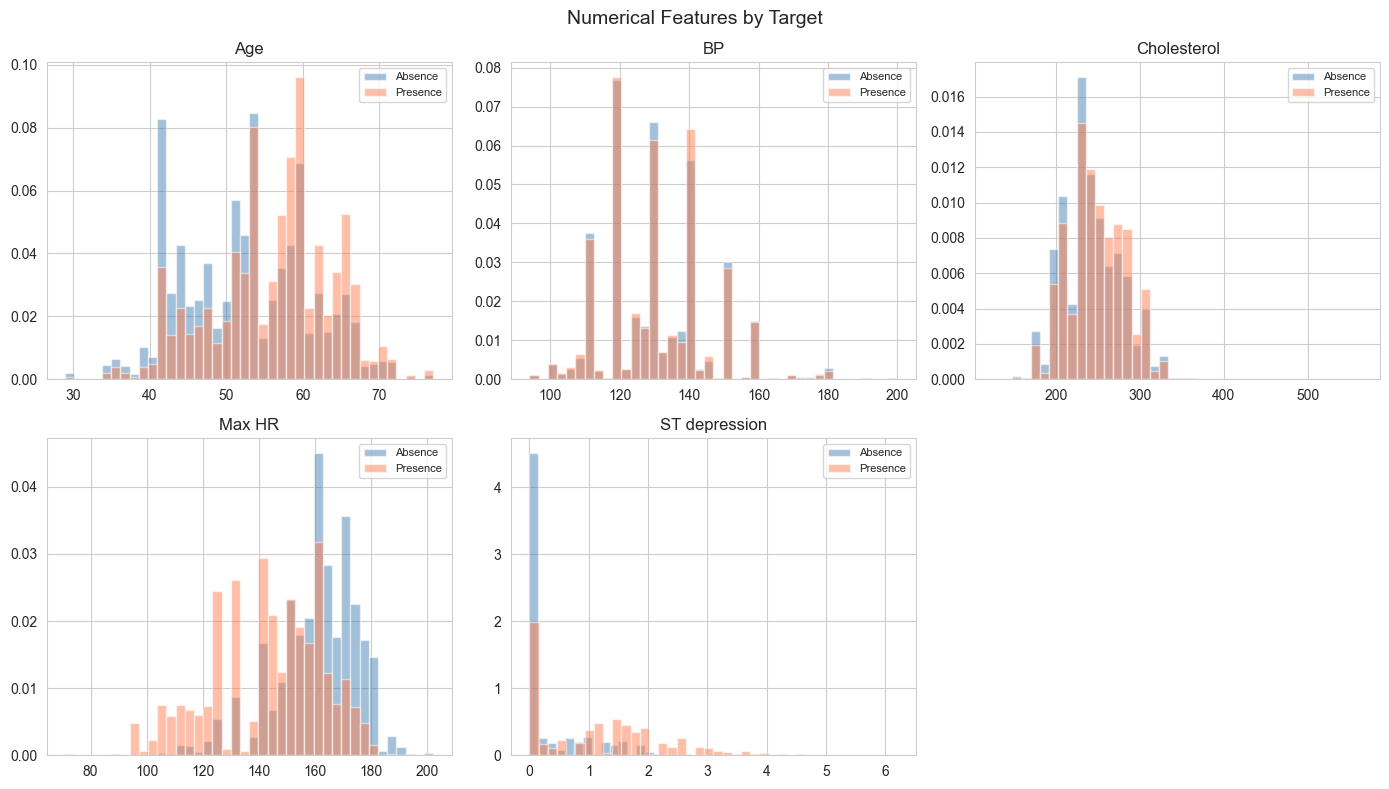

In [6]:
features = ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
            'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
            'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

numerical = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical = [f for f in features if f not in numerical]

# Numerical features: overlapping histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(numerical):
    ax = axes[i // 3, i % 3]
    for label, color in [('Absence', 'steelblue'), ('Presence', 'coral')]:
        subset = train[train['Heart Disease'] == label][col]
        ax.hist(subset, bins=40, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
axes[1, 2].axis('off')
plt.suptitle('Numerical Features by Target', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

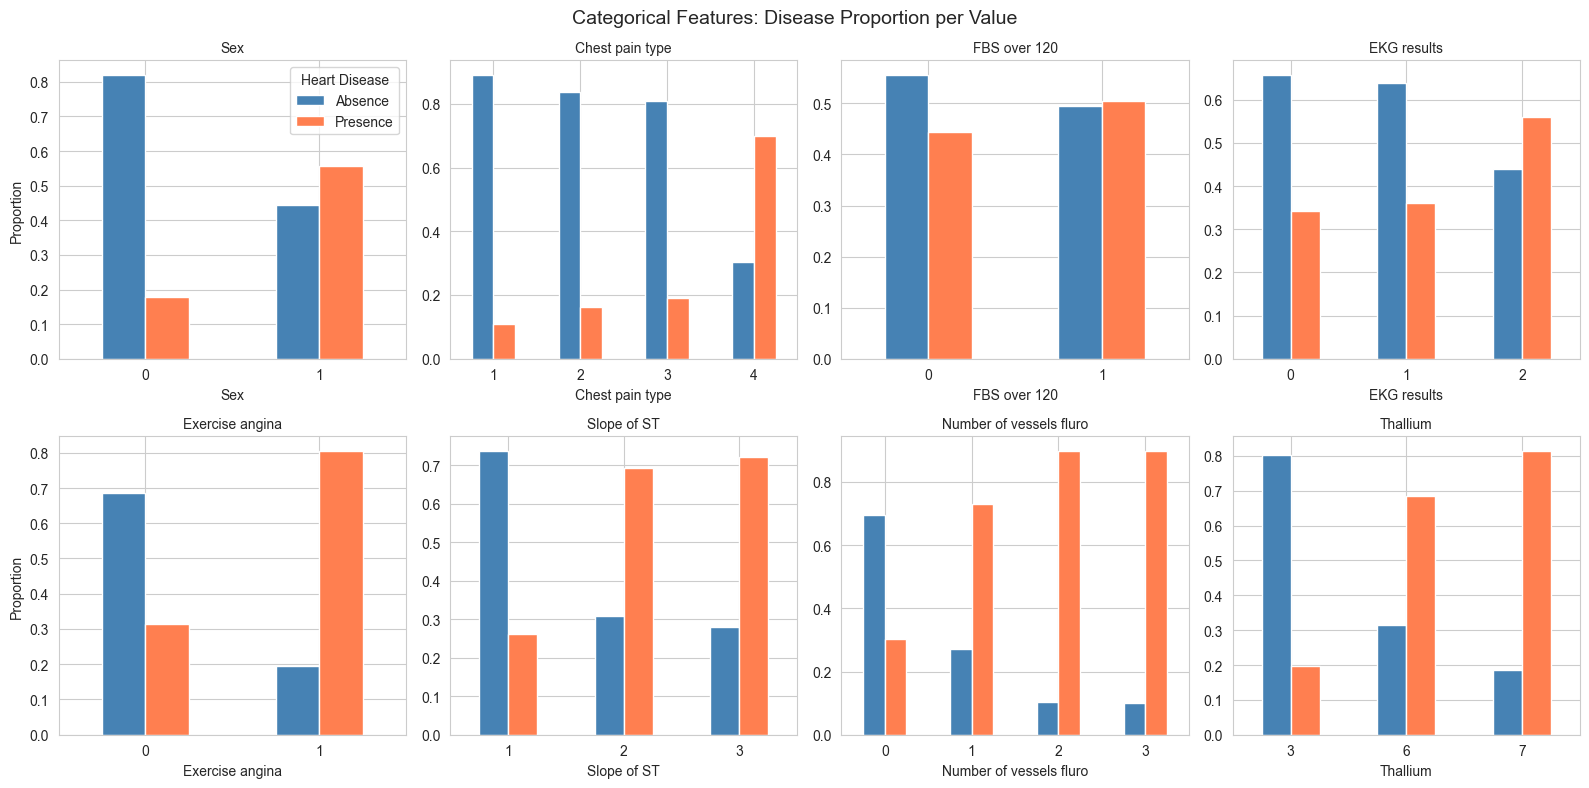

In [7]:
# Categorical features: grouped bar charts
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(categorical):
    ax = axes[i // 4, i % 4]
    ct = pd.crosstab(train[col], train['Heart Disease'], normalize='index')
    ct.plot.bar(ax=ax, color=['steelblue', 'coral'], legend=(i == 0))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Proportion' if i % 4 == 0 else '')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Categorical Features: Disease Proportion per Value', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Matrix

Pearson correlations between all numeric features and the binary target.

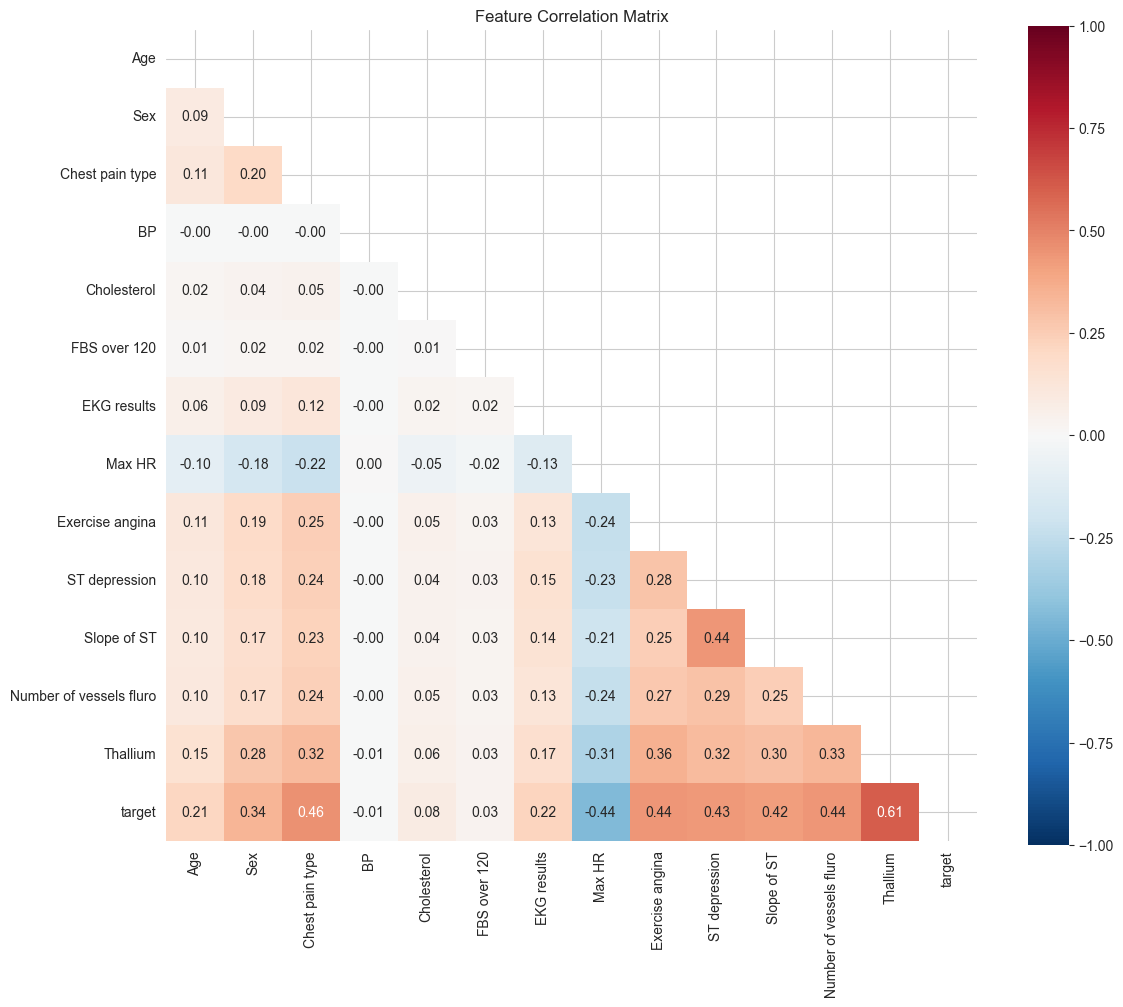

In [8]:
# Create numeric version for correlation
train_num = train.copy()
train_num['target'] = (train_num['Heart Disease'] == 'Presence').astype(int)
train_num = train_num[features + ['target']]

# Force numeric
for col in train_num.columns:
    train_num[col] = pd.to_numeric(train_num[col], errors='coerce')

corr = train_num.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Competition vs Original UCI

The competition dataset was generated using CTGAN from the original 270-row
UCI Cleveland dataset. Compare the distributions to check synthetic fidelity.

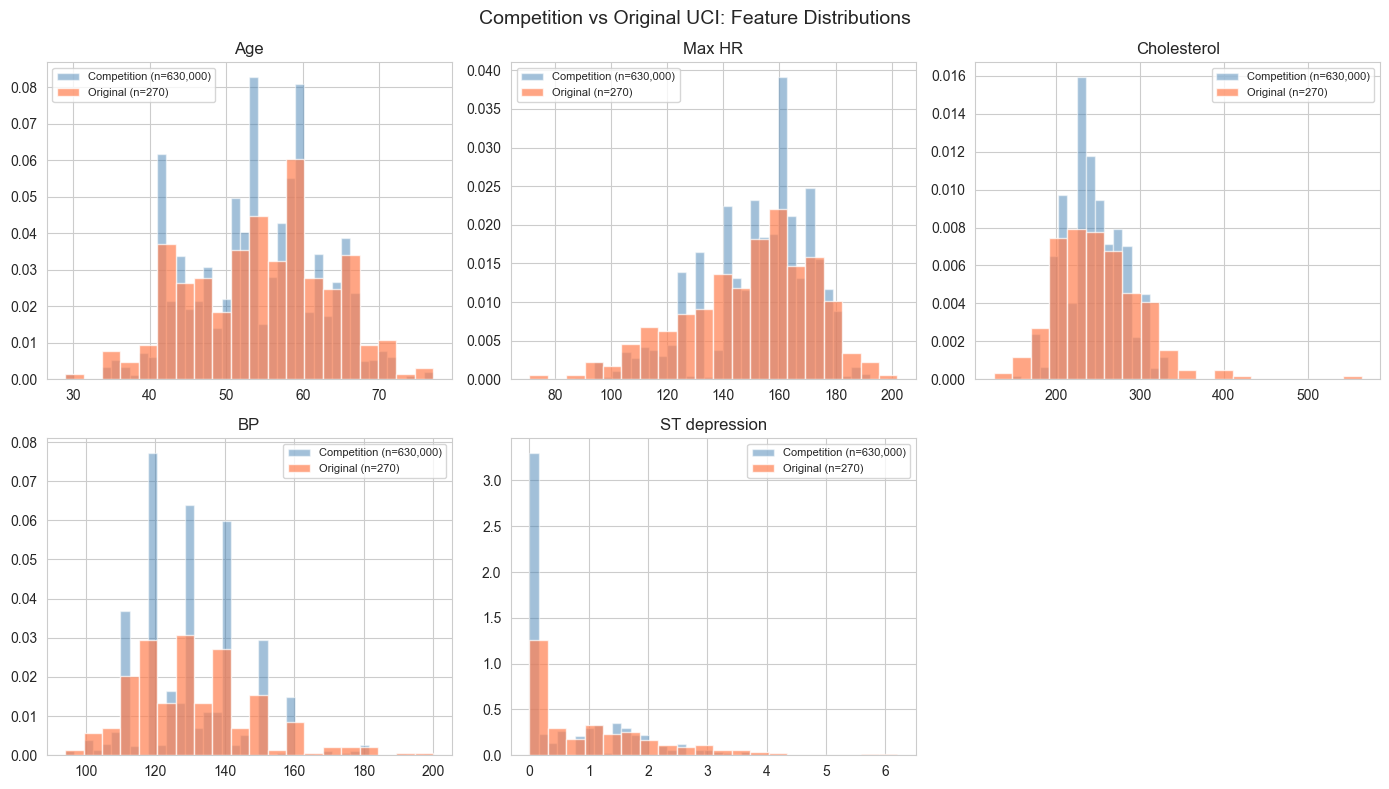

In [9]:
# Compare key feature distributions: competition vs original
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
compare_cols = ['Age', 'Max HR', 'Cholesterol', 'BP', 'ST depression']

# Standardize original target to match competition naming
orig_target = original['Heart Disease']

for i, col in enumerate(compare_cols):
    ax = axes[i // 3, i % 3]
    comp_vals = pd.to_numeric(train[col], errors='coerce').dropna()
    orig_vals = pd.to_numeric(original[col], errors='coerce').dropna()
    ax.hist(comp_vals, bins=40, alpha=0.5, label=f'Competition (n={len(comp_vals):,})', density=True, color='steelblue')
    ax.hist(orig_vals, bins=20, alpha=0.7, label=f'Original (n={len(orig_vals)})', density=True, color='coral')
    ax.set_title(col)
    ax.legend(fontsize=8)
axes[1, 2].axis('off')
plt.suptitle('Competition vs Original UCI: Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/competition_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Key observations:
- 630K samples, 13 clinical features, binary target (near-balanced)
- No missing values in competition data
- Continuous features (Age, Max HR, ST depression) show clear separation by target
- Categorical features like Thallium, Chest pain type, and Number of vessels have strong target association
- Distributions are faithful to the original UCI Cleveland data